In [86]:
import pandas as pd
import numpy as np
from mlxtend.plotting import plot_decision_regions

In [87]:
df=pd.DataFrame()

In [88]:
df['col1']=[1,2,3,4,5,4,5,6,7,8,8,8,9]
df['col2']=[2,3,4,6,5,4,3,2,3,4,5,6,7]
df['lable']=[1,1,0,1,0,0,1,1,0,0,0,1,1]

In [89]:
df

,col1,col2,lable
0,1,2,1
1,2,3,1
2,3,4,0
3,4,6,1
4,5,5,0
5,4,4,0
6,5,3,1
7,6,2,1
8,7,3,0
9,8,4,0


<Axes: xlabel='col1', ylabel='col2'>

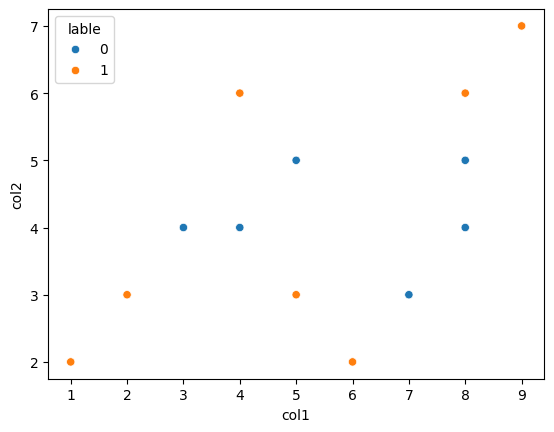

In [90]:
import seaborn as sns
sns.scatterplot(x=df['col1'],y=df['col2'] ,hue=df['lable'])

In [91]:
df['Weight']=1/df.shape[0]

In [92]:
df

,col1,col2,lable,Weight
0,1,2,1,0.076923
1,2,3,1,0.076923
2,3,4,0,0.076923
3,4,6,1,0.076923
4,5,5,0,0.076923
5,4,4,0,0.076923
6,5,3,1,0.076923
7,6,2,1,0.076923
8,7,3,0,0.076923
9,8,4,0,0.076923


[Text(0.5, 0.75, 'x[1] <= 5.5\ngini = 0.497\nsamples = 13\nvalue = [6, 7]'),
 Text(0.25, 0.25, 'gini = 0.48\nsamples = 10\nvalue = [6, 4]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.625, 0.5, '  False')]

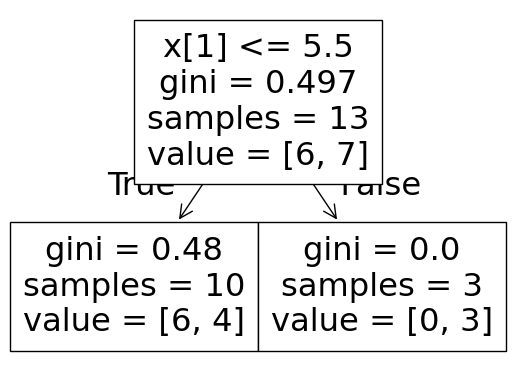

In [93]:
from sklearn.tree import plot_tree
from sklearn.tree import DecisionTreeClassifier
dt1=DecisionTreeClassifier(max_depth=1)
x=df.iloc[:,0:2].values
y=df.iloc[:,2].values
dt1.fit(x,y)
plot_tree(dt1)


In [94]:
y

array([1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1])

<Axes: >

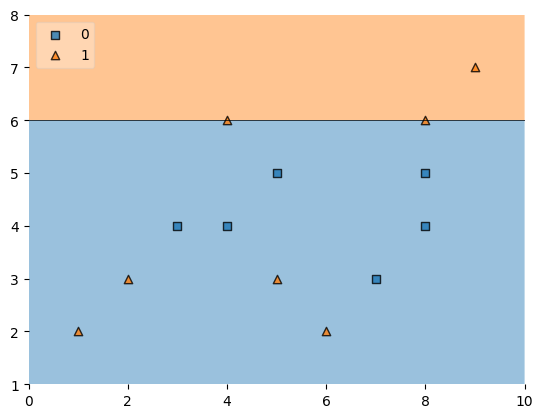

In [95]:
plot_decision_regions(x,y,clf=dt1,legend=2)

###  চারটা  ভুল  করছে  আমার ট্রি  আমরা  এবার  দেখব  এটা  কেমন  কাজ  করে

In [96]:
df['label_1']=dt1.predict(x)
df.drop('prediction_1',axis=1)

KeyError: "['prediction_1'] not found in axis"

In [97]:
df

,col1,col2,lable,Weight,label_1
0,1,2,1,0.076923,0
1,2,3,1,0.076923,0
2,3,4,0,0.076923,0
3,4,6,1,0.076923,1
4,5,5,0,0.076923,0
5,4,4,0,0.076923,0
6,5,3,1,0.076923,0
7,6,2,1,0.076923,0
8,7,3,0,0.076923,0
9,8,4,0,0.076923,0


In [98]:
def calculate_weight(error):
    return 0.5*np.log((1-error)/error)
    
    

In [99]:
#calculate alpha 
alpha1=calculate_weight(4*0.076924)
alpha1

np.float64(0.4054564414703863)

In [135]:
def update_row_w(row,alpha=0.405456):
    if row["lable"] ==row["y_pred"]:
        return row['Weight']*np.exp(-alpha)
    else:
        return row['Weight']*np.exp(alpha)

In [101]:
df['update_weight']=df.apply(update_row_w,axis=1)

In [102]:
df

,col1,col2,lable,Weight,label_1,update_weight
0,1,2,1,0.076923,0,0.115384
1,2,3,1,0.076923,0,0.115384
2,3,4,0,0.076923,0,0.051283
3,4,6,1,0.076923,1,0.051283
4,5,5,0,0.076923,0,0.051283
5,4,4,0,0.076923,0,0.051283
6,5,3,1,0.076923,0,0.115384
7,6,2,1,0.076923,0,0.115384
8,7,3,0,0.076923,0,0.051283
9,8,4,0,0.076923,0,0.051283


In [103]:
sum_uw=df['update_weight'].sum()
df['normalized_weight']=df['update_weight']/sum_uw

In [104]:
df

,col1,col2,lable,Weight,label_1,update_weight,normalized_weight
0,1,2,1,0.076923,0,0.115384,0.124999
1,2,3,1,0.076923,0,0.115384,0.124999
2,3,4,0,0.076923,0,0.051283,0.055556
3,4,6,1,0.076923,1,0.051283,0.055556
4,5,5,0,0.076923,0,0.051283,0.055556
5,4,4,0,0.076923,0,0.051283,0.055556
6,5,3,1,0.076923,0,0.115384,0.124999
7,6,2,1,0.076923,0,0.115384,0.124999
8,7,3,0,0.076923,0,0.051283,0.055556
9,8,4,0,0.076923,0,0.051283,0.055556


In [105]:
df['normalized_weight'].sum()

np.float64(1.0000000000000002)

In [106]:
df['custom_upper']=np.cumsum(df['normalized_weight'])
df['custom_lower']=df['custom_upper']-df['normalized_weight']

In [107]:
df

,col1,col2,lable,Weight,label_1,update_weight,normalized_weight,custom_upper,custom_lower
0,1,2,1,0.076923,0,0.115384,0.124999,0.124999,0.000000
1,2,3,1,0.076923,0,0.115384,0.124999,0.249998,0.124999
2,3,4,0,0.076923,0,0.051283,0.055556,0.305554,0.249998
3,4,6,1,0.076923,1,0.051283,0.055556,0.361110,0.305554
4,5,5,0,0.076923,0,0.051283,0.055556,0.416666,0.361110
5,4,4,0,0.076923,0,0.051283,0.055556,0.472222,0.416666
6,5,3,1,0.076923,0,0.115384,0.124999,0.597221,0.472222
7,6,2,1,0.076923,0,0.115384,0.124999,0.722220,0.597221
8,7,3,0,0.076923,0,0.051283,0.055556,0.777776,0.722220
9,8,4,0,0.076923,0,0.051283,0.055556,0.833332,0.777776


In [108]:
df[['col1','col2','lable','Weight','update_weight','custom_upper','custom_lower']]

,col1,col2,lable,Weight,update_weight,custom_upper,custom_lower
0,1,2,1,0.076923,0.115384,0.124999,0.000000
1,2,3,1,0.076923,0.115384,0.249998,0.124999
2,3,4,0,0.076923,0.051283,0.305554,0.249998
3,4,6,1,0.076923,0.051283,0.361110,0.305554
4,5,5,0,0.076923,0.051283,0.416666,0.361110
5,4,4,0,0.076923,0.051283,0.472222,0.416666
6,5,3,1,0.076923,0.115384,0.597221,0.472222
7,6,2,1,0.076923,0.115384,0.722220,0.597221
8,7,3,0,0.076923,0.051283,0.777776,0.722220
9,8,4,0,0.076923,0.051283,0.833332,0.777776


In [109]:
def create_new_dataset(df):
    indices=[]
    for i in range(df.shape[0]):
        a=np.random.random()
        for index,row in df.iterrows():
            if row['custom_upper']> a and a>row['custom_lower']:
                indices.append(index)
    return indices

In [121]:
index_values=create_new_dataset(df)
index_values

[0, 11, 7, 7, 7, 6, 11, 7, 1, 2, 8, 10, 10]

In [122]:
df2=df.iloc[index_values,[0,1,2,3]]

In [123]:
df2

,col1,col2,lable,Weight
0,1,2,1,0.076923
11,8,6,1,0.076923
7,6,2,1,0.076923
7,6,2,1,0.076923
7,6,2,1,0.076923
6,5,3,1,0.076923
11,8,6,1,0.076923
7,6,2,1,0.076923
1,2,3,1,0.076923
2,3,4,0,0.076923


In [125]:
x2=df2.iloc[:,0:2].values
y2=df2.iloc[:,2].values

In [126]:
dt2=DecisionTreeClassifier(max_depth=1)
dt2.fit(x2,y2)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[1] <= 2.5\ngini = 0.426\nsamples = 13\nvalue = [4, 9]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.5\nsamples = 8\nvalue = [4, 4]'),
 Text(0.625, 0.5, '  False')]

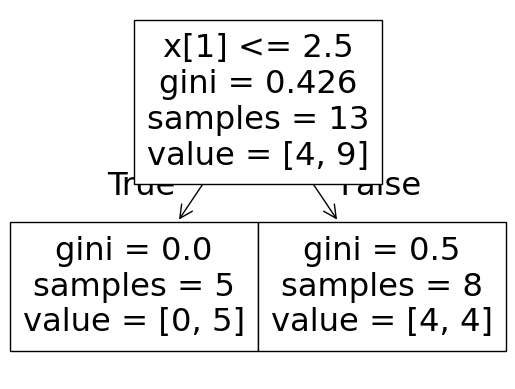

In [127]:
plot_tree(dt2)

<Axes: >

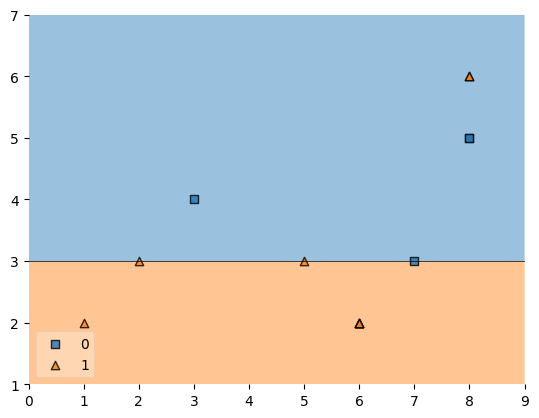

In [129]:
plot_decision_regions(x2,y2,clf=dt2,legend=3)

In [130]:
df2['y_pred']=dt2.predict(x)

In [131]:
df2

,col1,col2,lable,Weight,y_pred
0,1,2,1,0.076923,1
11,8,6,1,0.076923,0
7,6,2,1,0.076923,1
7,6,2,1,0.076923,1
7,6,2,1,0.076923,1
6,5,3,1,0.076923,0
11,8,6,1,0.076923,0
7,6,2,1,0.076923,1
1,2,3,1,0.076923,0
2,3,4,0,0.076923,0


In [143]:
alpha2=calculate_weight(4*0.076923)

In [144]:
alpha2

np.float64(0.40546583033058714)

In [145]:
df2['update_weight']=df2.apply(update_row_w,axis=1)

In [146]:
df2

,col1,col2,lable,Weight,y_pred,update_weight,normalized_weight,custom_upper,custom_lower
0,1,2,1,0.076923,1,0.051283,0.055556,0.055556,0.000000
11,8,6,1,0.076923,0,0.115384,0.124999,0.180555,0.055556
7,6,2,1,0.076923,1,0.051283,0.055556,0.236111,0.180555
7,6,2,1,0.076923,1,0.051283,0.055556,0.291667,0.236111
7,6,2,1,0.076923,1,0.051283,0.055556,0.347223,0.291667
6,5,3,1,0.076923,0,0.115384,0.124999,0.472222,0.347223
11,8,6,1,0.076923,0,0.115384,0.124999,0.597221,0.472222
7,6,2,1,0.076923,1,0.051283,0.055556,0.652777,0.597221
1,2,3,1,0.076923,0,0.115384,0.124999,0.777776,0.652777
2,3,4,0,0.076923,0,0.051283,0.055556,0.833332,0.777776


In [147]:
sum_uw=df2['update_weight'].sum()
df2['normalized_weight']=df2['update_weight']/sum_uw

In [148]:
df2['custom_upper']=np.cumsum(df2['normalized_weight'])
df2['custom_lower']=df2['custom_upper']-df2['normalized_weight']

In [149]:
df2[['col1','col2','lable','Weight','update_weight','custom_upper','custom_lower']]

,col1,col2,lable,Weight,update_weight,custom_upper,custom_lower
0,1,2,1,0.076923,0.051283,0.055556,0.000000
11,8,6,1,0.076923,0.115384,0.180555,0.055556
7,6,2,1,0.076923,0.051283,0.236111,0.180555
7,6,2,1,0.076923,0.051283,0.291667,0.236111
7,6,2,1,0.076923,0.051283,0.347223,0.291667
6,5,3,1,0.076923,0.115384,0.472222,0.347223
11,8,6,1,0.076923,0.115384,0.597221,0.472222
7,6,2,1,0.076923,0.051283,0.652777,0.597221
1,2,3,1,0.076923,0.115384,0.777776,0.652777
2,3,4,0,0.076923,0.051283,0.833332,0.777776


In [150]:
index_values=create_new_dataset(df2)

In [151]:
index_values

[1, 11, 1, 1, 7, 11, 1, 2, 11, 10, 10, 6, 11]

In [153]:
df3=df2.iloc[index_values,[0,1,2,3]]

In [155]:
df3

,col1,col2,lable,Weight
11,8,6,1,0.076923
10,8,5,0,0.076923
11,8,6,1,0.076923
11,8,6,1,0.076923
7,6,2,1,0.076923
10,8,5,0,0.076923
11,8,6,1,0.076923
7,6,2,1,0.076923
10,8,5,0,0.076923
8,7,3,0,0.076923


In [156]:
x3=df3.iloc[:,0:2].values
y3=df3.iloc[:,2].values

In [157]:
dt3=DecisionTreeClassifier(max_depth=1)
dt3.fit(x3,y3)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[1] <= 5.5\ngini = 0.497\nsamples = 13\nvalue = [6, 7]'),
 Text(0.25, 0.25, 'gini = 0.375\nsamples = 8\nvalue = [6, 2]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.625, 0.5, '  False')]

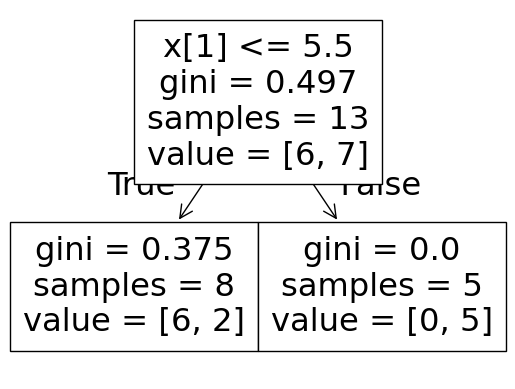

In [158]:
plot_tree(dt3,max_depth=1)

<Axes: >

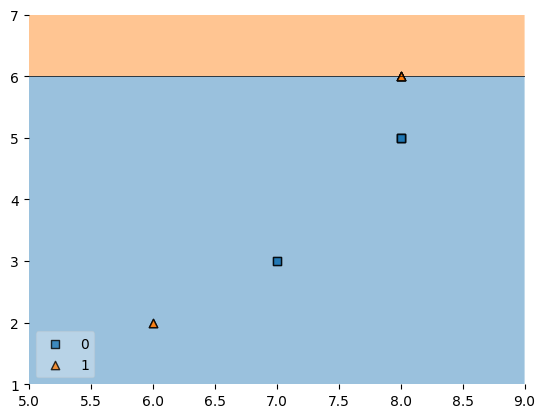

In [160]:
plot_decision_regions(x3,y3,clf=dt3,legend=3)